In [1]:
# Supress Warnings

import warnings
warnings.filterwarnings('ignore')

In [3]:
# importing all libraries and mysql connector

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mysql.connector

In [11]:
# establishing connection

connection = mysql.connector.connect(host = "localhost", port = 3306, user = "root", password = "Anubhav@7390", database = "sales_data")

In [13]:
df = pd.read_sql_query("select * from sales", connection)
df

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,ADDRESSLINE1,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
0,10107,30,95.70,2,2871.00,2/24/2003 0:00,Shipped,1,2,2003,...,897 Long Airport Avenue,,NYC,NY,10022,USA,NA,Yu,Kwai,Small
1,10121,34,81.35,5,2765.90,5/7/2003 0:00,Shipped,2,5,2003,...,59 rue de l'Abbaye,,Reims,,51100,France,EMEA,Henriot,Paul,Small
2,10134,41,94.74,2,3884.34,7/1/2003 0:00,Shipped,3,7,2003,...,27 rue du Colonel Pierre Avia,,Paris,,75508,France,EMEA,Da Cunha,Daniel,Medium
3,10145,45,83.26,6,3746.70,8/25/2003 0:00,Shipped,3,8,2003,...,78934 Hillside Dr.,,Pasadena,CA,90003,USA,NA,Young,Julie,Medium
4,10159,49,100.00,14,5205.27,10/10/2003 0:00,Shipped,4,10,2003,...,7734 Strong St.,,San Francisco,CA,,USA,NA,Brown,Julie,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2818,10350,20,100.00,15,2244.40,12/2/2004 0:00,Shipped,4,12,2004,...,"C/ Moralzarzal, 86",,Madrid,,28034,Spain,EMEA,Freyre,Diego,Small
2819,10373,29,100.00,1,3978.51,1/31/2005 0:00,Shipped,1,1,2005,...,Torikatu 38,,Oulu,,90110,Finland,EMEA,Koskitalo,Pirkko,Medium
2820,10386,43,100.00,4,5417.57,3/1/2005 0:00,Resolved,1,3,2005,...,"C/ Moralzarzal, 86",,Madrid,,28034,Spain,EMEA,Freyre,Diego,Medium
2821,10397,34,62.24,1,2116.16,3/28/2005 0:00,Shipped,1,3,2005,...,1 rue Alsace-Lorraine,,Toulouse,,31000,France,EMEA,Roulet,Annette,Small


In [41]:
df = pd.read_sql_query('select productline, sum(quantityordered) as total_quantity , round(sum(sales), 2) as Total_Sales from sales group by productline', connection)
df

,productline,total_quantity,Total_Sales
0,Motorcycles,11663.0,1166388.34
1,Classic Cars,33992.0,3919615.66
2,Trucks and Buses,10777.0,1127789.84
3,Vintage Cars,21069.0,1903150.84
4,Planes,10727.0,975003.57
5,Ships,8127.0,714437.13
6,Trains,2712.0,226243.47


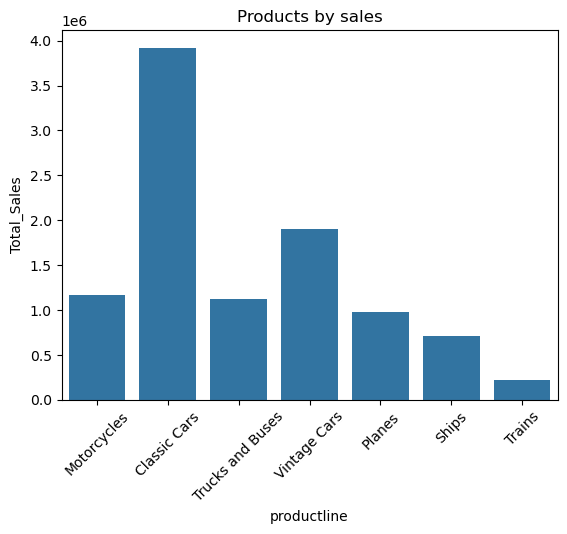

In [43]:
sns.barplot(x = 'productline', y = 'Total_Sales', data = df)
plt.xticks(rotation = 45)
plt.title('Products by sales')
plt.show()

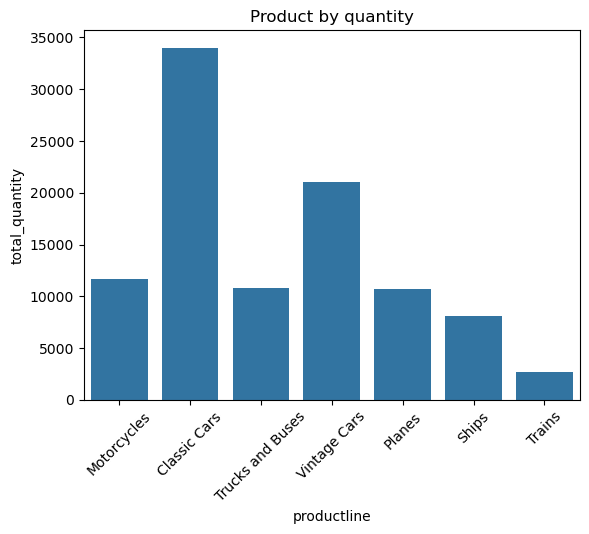

In [27]:
sns.barplot(x = 'productline', y = 'total_quantity', data = df)
plt.xticks(rotation = 45)
plt.title('Product by quantity')
plt.show()

In [47]:
df = pd.read_sql_query('select Month_id , round(sum(sales), 2) as Total_Sales from sales group by Month_id order by Month_id;', connection)
df

,Month_id,Total_Sales
0,1,785874.44
1,2,810441.90
2,3,754501.39
3,4,669390.96
4,5,923972.56
5,6,454756.78
6,7,514875.97
7,8,659310.57
8,9,584724.27
9,10,1121215.22


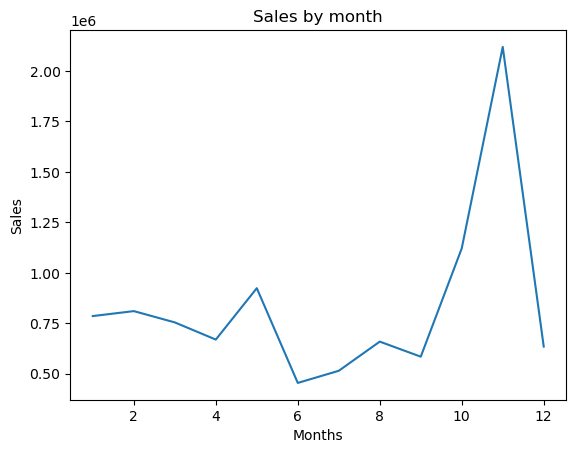

In [55]:
# sales by months.

plt.plot(df["Month_id"], df["Total_Sales"])
plt.title("Sales by month")
plt.xlabel("Months")
plt.ylabel("Sales")
plt.show()

In [67]:
df = pd.read_sql_query("select Status, sum(quantityordered) as Total_Orders from sales group by Status", connection)
df

,Status,Total_Orders
0,Shipped,91403.0
1,Disputed,597.0
2,In Process,1490.0
3,Cancelled,2038.0
4,On Hold,1879.0
5,Resolved,1660.0


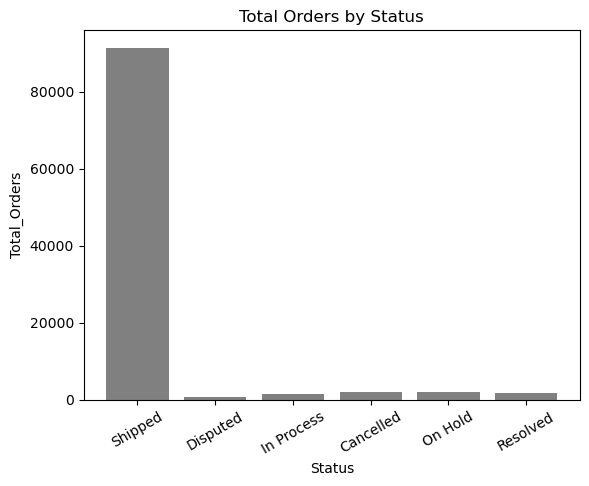

In [89]:
# total number of orders by their status.

plt.bar(df["Status"], df["Total_Orders"], color = "grey")
plt.title('Total Orders by Status')
plt.xlabel('Status')
plt.ylabel('Total_Orders')
plt.xticks(rotation = 30)
plt.show()

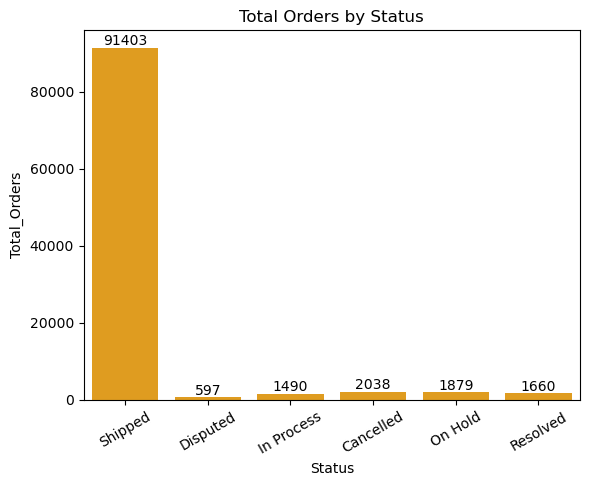

In [81]:
# same plot through Seaborn.

ax = sns.barplot(x = "Status", y = "Total_Orders", data = df, color = "Orange")
plt.title('Total Orders by Status')
plt.xticks(rotation = 30)
ax.bar_label(ax.containers[0])
plt.show()